<a href="https://colab.research.google.com/github/vinipi/flight_delay_prediction/blob/main/poc_pollution_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)

In [ ]:
# Cell 2 — Load CSV

CSV_PATH = "AirQualityUCI.csv"

# Specifying sep=";" and decimal="," because European formatted CSVs use commas for decimals.
df = pd.read_csv(CSV_PATH, sep=";", decimal=",")

# Remove empty columns such as the trailing column in some UCI versions
df = df.dropna(axis=1, how="all")

print(df.shape)
print(df.columns.tolist())
df.head()

(9471, 15)
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [ ]:
# Cell 3 — Parse date/time and convert measurements

df.columns = [str(c).strip() for c in df.columns]

# The dataset uses dots for times (e.g. 18.00.00), so we replace them with colons first
clean_time = df["Time"].astype(str).str.replace(".", ":", regex=False)

df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + clean_time,
    dayfirst=True,
    errors="coerce"
)

for col in df.columns:
    if col not in ["Date", "Time", "datetime"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = (
    df.dropna(subset=["datetime"])
      .sort_values("datetime")
      .drop_duplicates("datetime")
      .set_index("datetime")
)

# UCI uses -200 for missing measurements
measurement_cols = [
    c for c in df.columns
    if c not in ["Date", "Time"]
]

for col in measurement_cols:
    df.loc[df[col] == -200, col] = np.nan

print(df.shape)
print(df.index.min(), "→", df.index.max())

(9357, 15)
2004-03-10 18:00:00 → 2005-04-04 14:00:00


In [ ]:
# Check the actual distribution of NO2

print(df["NO2(GT)"].describe())

print("\nPercentiles:")
print(
    df["NO2(GT)"]
    .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

print("\nMissing:")
print(df["NO2(GT)"].isna().sum())

count    7715.000000
mean      113.091251
std        48.370108
min         2.000000
25%        78.000000
50%       109.000000
75%       142.000000
max       340.000000
Name: NO2(GT), dtype: float64

Percentiles:
0.01     26.00
0.05     43.00
0.10     55.00
0.25     78.00
0.50    109.00
0.75    142.00
0.90    178.00
0.95    200.30
0.99    245.86
Name: NO2(GT), dtype: float64

Missing:
1642


In [ ]:
# Cell 4 — Create the 24-hour NO2 target

# 24h rolling NO2 mean
df["NO2_24h"] = (
    df["NO2(GT)"]
    .rolling(window=24, min_periods=18)
    .mean()
)

# Define unusually high NO2 as the top 10% of 24h averages
THRESHOLD_NO2 = df["NO2_24h"].quantile(0.60)

print("90th percentile NO2 24h threshold:", THRESHOLD_NO2)

# Predict high NO2 6 hours ahead
df["target"] = (
    df["NO2_24h"].shift(-6) >= THRESHOLD_NO2
).astype(float)

# Remove rows where the target cannot be calculated
df.loc[df["NO2_24h"].isna(), "target"] = np.nan

print(df["target"].value_counts(normalize=True))

90th percentile NO2 24h threshold: 118.91304347826087
target
0.0    0.603007
1.0    0.396993
Name: proportion, dtype: float64


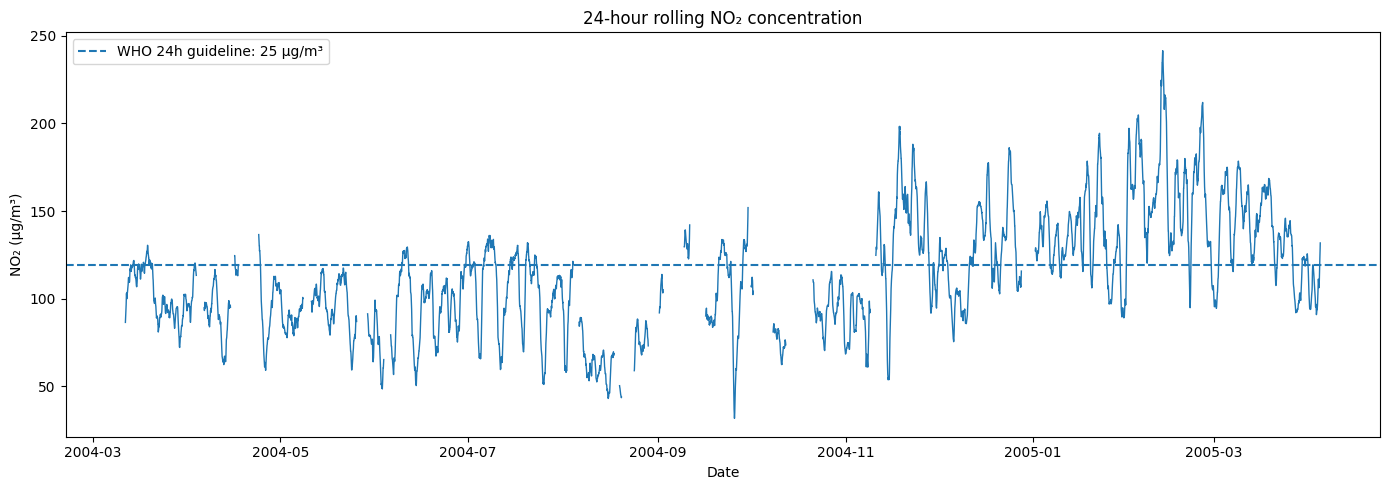

In [ ]:
# Cell 5 — Visualize the NO2 threshold

plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["NO2_24h"],
    linewidth=1
)

plt.axhline(
    THRESHOLD_NO2,
    linestyle="--",
    label="WHO 24h guideline: 25 µg/m³"
)

plt.title("24-hour rolling NO₂ concentration")
plt.ylabel("NO₂ (µg/m³)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6 — Create features

base_features = [
    "CO(GT)",
    "C6H6(GT)",
    "NOx(GT)",
    "NO2(GT)",
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
]

feature_cols = []

# Current + historical measurements
lags = [0, 1, 3, 6, 12, 24]

for col in base_features:
    for lag in lags:

        name = f"{col}_lag{lag}"

        df[name] = df[col].shift(lag)

        feature_cols.append(name)

# Time features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

# Cyclic time encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

feature_cols += [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month",
]

print("Number of features:", len(feature_cols))

Number of features: 77


In [ ]:
# Cell 7 — Build model dataset

model_df = df[
    feature_cols + ["target"]
].dropna(subset=["target"])

X = model_df[feature_cols]
y = model_df["target"].astype(int)

print("Rows:", len(model_df))
print("Features:", len(feature_cols))

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Rows: 7781
Features: 77

Target distribution:
target
0    4692
1    3089
Name: count, dtype: int64

Target percentage:
target
0    60.300733
1    39.699267
Name: proportion, dtype: float64


In [ ]:
# Cell 8 — Time-based train/test split

# IMPORTANT:
# Do NOT randomly split time-series data.

split_idx = int(len(model_df) * 0.80)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training:")
print(X_train.index.min(), "→", X_train.index.max())

print("\nTesting:")
print(X_test.index.min(), "→", X_test.index.max())

print("\nTrain positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Training:
2004-03-11 12:00:00 → 2005-01-29 17:00:00

Testing:
2005-01-29 18:00:00 → 2005-04-04 14:00:00

Train positive rate: 0.2943444730077121
Test positive rate: 0.8073217726396917


In [ ]:
# Cell 9 — Train Random Forest

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

model.fit(X_train, y_train)

# Probability of exceeding the NO2 threshold
probability = model.predict_proba(X_test)[:, 1]

# Default threshold
prediction = (probability >= 0.5).astype(int)

In [ ]:
# Cell 10 — Evaluate

#for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#    y_pred = (probability >= threshold).astype(int)#
#
#    print(f"\nThreshold: {threshold}")
#    print(classification_report(
#        y_test,
#        y_pred,
#        target_names=["Below threshold", "Exceeds threshold"]
#    ))

print(
    classification_report(
        y_test,
        prediction,
        target_names=[
            "Below threshold",
            "Exceeds threshold"
        ],
        zero_division=0
    )
)

roc_auc = roc_auc_score(
    y_test,
    probability
)

pr_auc = average_precision_score(
    y_test,
    probability
)

print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))

                   precision    recall  f1-score   support

  Below threshold       0.70      0.85      0.77       300
Exceeds threshold       0.96      0.91      0.94      1257

         accuracy                           0.90      1557
        macro avg       0.83      0.88      0.85      1557
     weighted avg       0.91      0.90      0.90      1557

ROC-AUC: 0.961
PR-AUC: 0.99


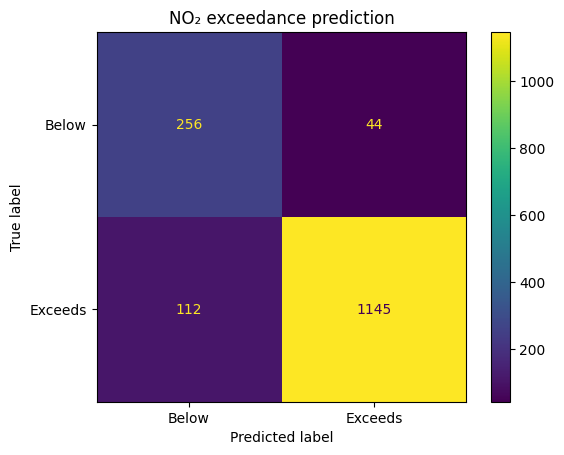

In [ ]:
# Cell 11 — Confusion matrix

cm = confusion_matrix(
    y_test,
    prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Below",
        "Exceeds"
    ]
)

disp.plot()

plt.title("NO₂ exceedance prediction")
plt.show()

NO2(GT)_lag12         0.089310
NO2(GT)_lag0          0.060035
NO2(GT)_lag6          0.059324
NO2(GT)_lag3          0.051603
NO2(GT)_lag1          0.041287
NOx(GT)_lag12         0.040586
NOx(GT)_lag6          0.037581
NOx(GT)_lag1          0.032932
T_lag24               0.029742
NOx(GT)_lag0          0.026046
NO2(GT)_lag24         0.024029
NOx(GT)_lag3          0.022823
AH_lag24              0.021406
T_lag12               0.020784
NOx(GT)_lag24         0.020161
month                 0.018020
PT08.S5(O3)_lag12     0.015532
T_lag6                0.015464
T_lag1                0.014999
T_lag0                0.014888
T_lag3                0.014088
AH_lag12              0.012925
PT08.S4(NO2)_lag24    0.012381
PT08.S5(O3)_lag6      0.011030
AH_lag0               0.010948
dtype: float64


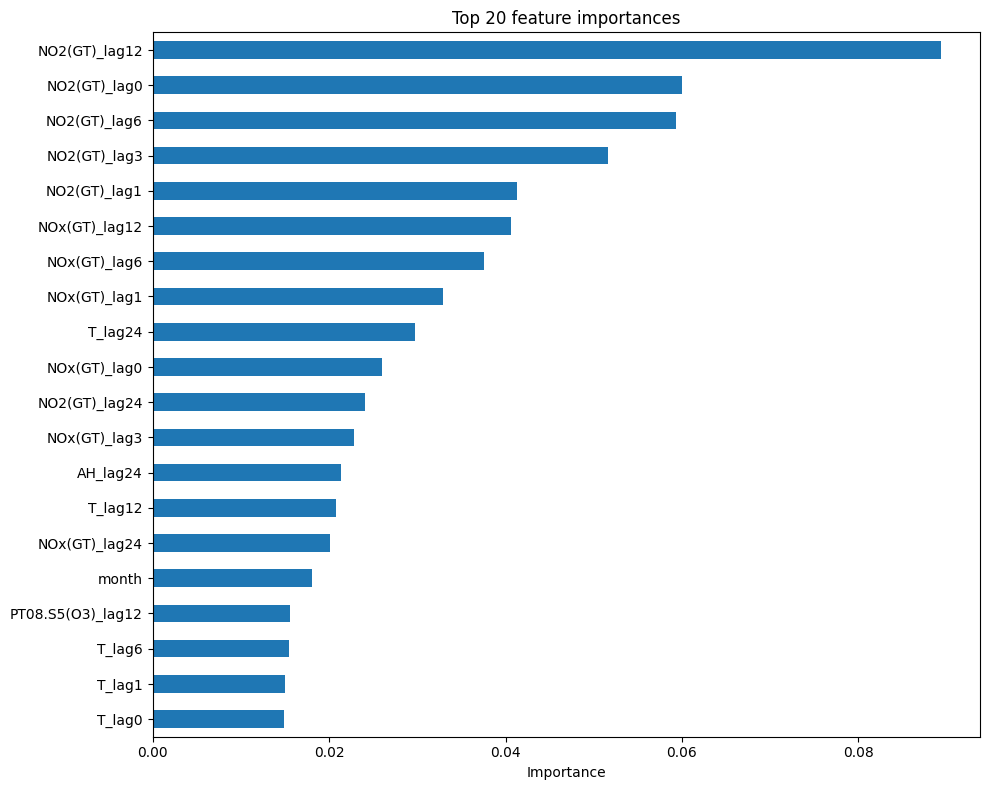

In [ ]:
# Cell 12 — Feature importance

rf = model.named_steps["classifier"]

importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(
    ascending=False
)

print(importance.head(25))

plt.figure(figsize=(10, 8))

importance.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Top 20 feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13 — Compare with a naive baseline

# Always predict the most common class
majority_class = y_train.mode()[0]

baseline_prediction = np.full(
    len(y_test),
    majority_class
)

print(
    classification_report(
        y_test,
        baseline_prediction,
        target_names=[
            "Below threshold",
            "Exceeds threshold"
        ],
        zero_division=0
    )
)

                   precision    recall  f1-score   support

  Below threshold       0.19      1.00      0.32       300
Exceeds threshold       0.00      0.00      0.00      1257

         accuracy                           0.19      1557
        macro avg       0.10      0.50      0.16      1557
     weighted avg       0.04      0.19      0.06      1557



In [ ]:
# Cell 14 — Inspect predictions over time

results = pd.DataFrame(
    {
        "actual": y_test,
        "probability": probability,
        "prediction": prediction,
    },
    index=y_test.index
)

results["actual_no2_24h"] = df.loc[
    results.index,
    "NO2_24h"
]

results["actual_exceedance"] = (
    results["actual_no2_24h"] > THRESHOLD_NO2
)

results.head()

,actual,probability,prediction,actual_no2_24h,actual_exceedance
datetime,,,,,
2005-01-29 18:00:00,0,0.226997,0,96.695652,False
2005-01-29 19:00:00,0,0.269448,0,93.913043,False
2005-01-29 20:00:00,0,0.328527,0,92.608696,False
2005-01-29 21:00:00,0,0.389073,0,92.043478,False
2005-01-29 22:00:00,0,0.324532,0,90.869565,False


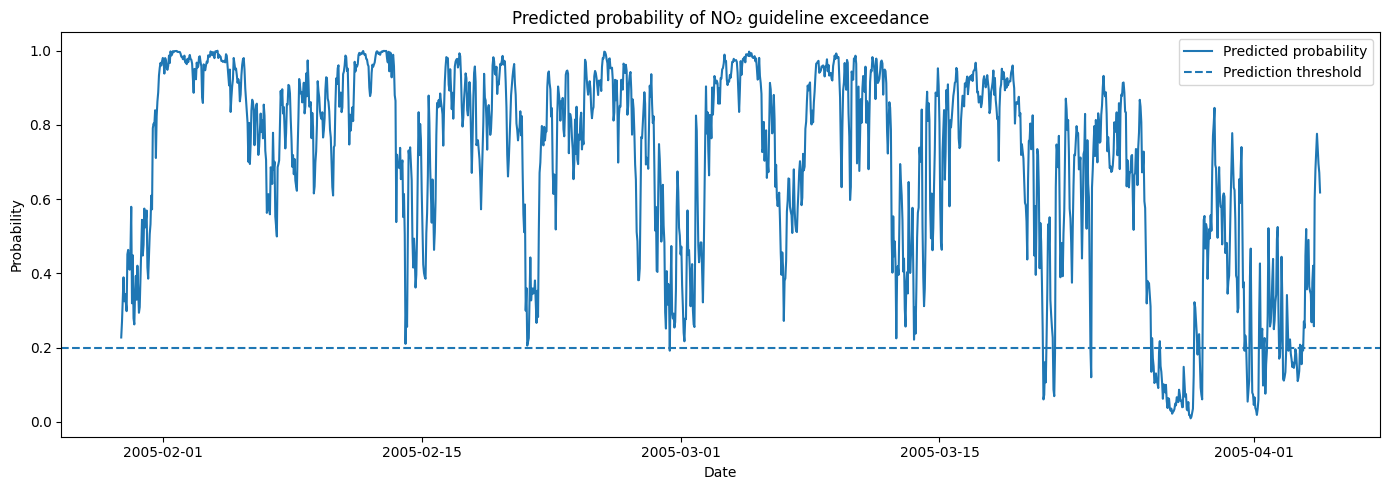

In [ ]:
# Cell 15 — Plot predicted probability

plt.figure(figsize=(14, 5))

plt.plot(
    results.index,
    results["probability"],
    label="Predicted probability"
)

plt.axhline(
    0.2,
    linestyle="--",
    label="Prediction threshold"
)

plt.title("Predicted probability of NO₂ guideline exceedance")
plt.ylabel("Probability")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()